<a href="https://colab.research.google.com/github/Megeeee/AICoach/blob/main/NeuroSSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [358]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU Name: {torch.cuda.get_device_name(0)}')


Using device: cuda
GPU Name: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [359]:
class SSMModule(nn.Module):
  def __init__(self,d_inner,d_state):
    super(SSMModule, self).__init__()

    self.d_inner = d_inner
    self.d_state = d_state

    self.s_delta = nn.Linear(d_inner,d_inner)
    self.s_gamma = nn.Linear(d_inner,d_inner)
    self.s_beta = nn.Linear(d_inner,d_inner)

    self.z = nn.Linear(d_inner,d_inner)

    self.softplus = nn.Softplus()

    self.Lambda = nn.Parameter(torch.randn(d_inner,d_state))

    self.s_out = nn.Linear(d_inner,d_inner)


  def forward(self,r_bar):

    B, T, D = r_bar.shape

    h_t = torch.zeros(B,D,self.d_state,device = r_bar.device)
    u_t = torch.zeros(B, T, D, device=r_bar.device)

    delta = self.s_delta(r_bar) #B T D
    gamma = self.s_gamma(r_bar)
    beta = self.s_beta(r_bar)
    z = self.z(r_bar)

    delta = self.softplus(delta) #make delta positive


    for t in range(T):

      r_bar_t = r_bar[:,t,:].unsqueeze(-1) #B D 1
      delta_t = delta[:,t,:].unsqueeze(-1)
      gamma_t = gamma[:,t,:]
      beta_t = beta[:,t,:].unsqueeze(-1)
      z_t = z[:,t,:]

      dL = delta_t * self.Lambda
      A_t = torch.exp(dL.clamp(max=20))
      P_t = (A_t - 1) / dL.clamp(min=1e-6) * beta_t

      h_t = A_t * h_t + P_t * r_bar_t
      h_t = h_t.clamp(-1e4, 1e4)  # prevent explosion
      u_t[:,t,:] = gamma_t * h_t.sum(-1)

      # --- DEBUG ---
      for name, val in [("delta_t", delta_t), ("dL", dL), ("A_t", A_t),
                        ("P_t", P_t), ("h_t", h_t), ("u_t", u_t[:,t,:])]:
          if torch.isnan(val).any() or torch.isinf(val).any():
              print(f"t={t} | NaN/Inf in {name} | min={val.min():.4f} max={val.max():.4f}")
              raise ValueError(f"Stopped at {name}")

    y = u_t * (z * torch.sigmoid(z))

    o = self.s_out(y)
    return o



In [360]:
class DUAL_SSM(nn.Module):
  def __init__(self,d_k,d_inner,d_state,d_conv):
    super(DUAL_SSM, self).__init__()

    self.ssm = SSMModule(d_inner,d_state)

    self.s_rescaled1 = nn.Linear(d_k,d_inner)
    self.s_diff1 = nn.Linear(d_k,d_inner)

    self.s_rescaled2 = nn.Linear(d_k,d_inner)
    self.s_diff2 = nn.Linear(d_k,d_inner)

    self.conv_rescaled = nn.Conv1d(d_inner,d_inner,kernel_size=d_conv,groups=d_inner,padding="same")
    self.conv_diff = nn.Conv1d(d_inner,d_inner,kernel_size=d_conv,groups=d_inner,padding="same")

    self.SiLU = nn.SiLU()

    self.proj_rescaled = nn.Linear(d_inner,d_k)
    self.proj_diff = nn.Linear(d_inner,d_k)


  def forward(self,B_rescaled,B_diff):
    X_rescaled = self.s_rescaled1(B_rescaled)
    X_diff = self.s_diff1(B_diff)

    X_rescaled_right = self.s_rescaled2(B_rescaled)
    X_diff_right = self.s_diff2(B_diff)

    X_rescaled_right = self.SiLU(X_rescaled_right)
    X_diff_right = self.SiLU(X_diff_right)

    X_rescaled_right = X_rescaled_right * X_rescaled
    X_diff_right = X_diff_right * X_diff

    X_rescaled = self.conv_rescaled(X_rescaled.transpose(1, 2)).transpose(1, 2)
    X_diff = self.conv_diff(X_diff.transpose(1, 2)).transpose(1, 2)

    X_rescaled = self.SiLU(X_rescaled)
    X_diff = self.SiLU(X_diff)

    U = self.ssm(X_rescaled)
    V = self.ssm(X_diff)

    U = U * X_rescaled_right
    V = V * X_diff_right

    U = self.proj_rescaled(U)
    V = self.proj_diff(V)

    Z = U + V
    return Z


In [361]:
class MSD_SSB (nn.Module):
  def __init__(self,t_k,N,d_conv,d_inner,d_state):
    super(MSD_SSB, self).__init__()
    self.t_k = t_k
    self.N = N

    self.DualSSM = DUAL_SSM(d_k = t_k* N,d_inner = d_inner,d_state= d_state,d_conv = d_conv)

  def forward(self,x):
    B_shape, T_shape, N_shape = x.shape

    B=x.reshape(B_shape,T_shape//self.t_k,self.t_k * N_shape)

    zeros = torch.zeros(B_shape, 1, self.t_k * N_shape, device=x.device)

    B_tminus1 = torch.cat((zeros,B[:,:-1,:]),dim=1)
    deltaB = B-B_tminus1

    out = self.DualSSM(B,deltaB)
    return out.reshape(B_shape,T_shape,N_shape)



In [362]:
class NeuroSSM_Block (nn.Module):
  def __init__(self,N,d_conv,expand,d_state,scales=[1,2,3]):
    super(NeuroSSM_Block, self).__init__()

    self.layerNorm1 = nn.LayerNorm(N)

    self.msd_ssbs = nn.ModuleList([
        MSD_SSB(
            t_k=tau,
            N=N,
            d_conv=d_conv,
            d_inner=expand * tau * N,
            d_state=d_state
        ) for tau in scales
    ])

    self.layerNorm2 = nn.LayerNorm(N)

    self.GELU = nn.GELU()


  def forward(self,x):
    x = self.layerNorm1(x)

    z= 0
    for msd_ssb in self.msd_ssbs:
      z = z + msd_ssb(x)

    z = self.layerNorm2(z)
    z= self.GELU(z)

    return z



In [363]:
class NeuroSSM(nn.Module):
  def __init__(self,L,N,d_conv,expand,d_state,scales=[1,2,3]):
    super(NeuroSSM, self).__init__()

    self.Modules = nn.ModuleList([
        NeuroSSM_Block(
            N=N,
            d_conv=d_conv,
            expand=expand,
            d_state=d_state,
            scales = scales
        ) for i in range(L)
    ])

    self.pool = nn.AdaptiveAvgPool1d(1)
    self.fc = nn.Linear(N,1)
    self.dropout = nn.Dropout(p=0.25)

  def forward(self,x):
    for module in self.Modules:
      x = module(x)

    y = x.mean(dim=1)
    y = self.dropout(y)
    out = self.fc(y)
    return out

In [364]:
!pip install nilearn

from nilearn import datasets
import torch

# 1. Download pre-extracted time-series from 10 subjects in the ABIDE dataset
# 'rois_cc200' means the brain is already parcellated into 200 regions!
print("Fetching dataset...")
abide = datasets.fetch_abide_pcp(derivatives=['rois_cc200'], n_subjects=200)

# 2. Extract the first subject's time-series matrix
# It arrives as a clean numpy array of shape (Time, N)
subject_1_data = abide.rois_cc200[0]

# 3. Convert to a PyTorch tensor and add the Batch dimension
tensor_data = torch.tensor(subject_1_data, dtype=torch.float32).unsqueeze(0)

print(f"Data is ready! Tensor Shape: {tensor_data.shape}")
# Output will be something like: [1, 196, 200]

Fetching dataset...


[fetch_abide_pcp] Dataset found in /root/nilearn_data/ABIDE_pcp

Data is ready! Tensor Shape: torch.Size([1, 196, 200])


In [365]:
import torch
from torch.utils.data import Dataset, DataLoader
from nilearn import datasets

class ABIDEDataset(Dataset):
    def __init__(self, n_subjects=50, seq_len=196):
        print(f"Downloading ABIDE data for {n_subjects} subjects...")
        self.abide_data = datasets.fetch_abide_pcp(derivatives=['rois_cc200'], n_subjects=n_subjects)

        self.seq_len = seq_len
        self.features = []
        self.labels = []

        # FIXED: Use zip() to grab the matrix and the label at the exact same time
        for ts_matrix, raw_label in zip(self.abide_data.rois_cc200, self.abide_data.phenotypic['DX_GROUP']):

            # 1. Process the time-series matrix
            tensor_x = torch.tensor(ts_matrix, dtype=torch.float32)

            # Skip if the sequence is shorter than our minimum length
            if tensor_x.shape[0] < self.seq_len:
                continue

            cropped_x = tensor_x[:self.seq_len, :]

            mean = cropped_x.mean(dim=0, keepdim=True)  # shape: (1, 200)
            std  = cropped_x.std(dim=0, keepdim=True) + 1e-8
            cropped_x = (cropped_x - mean) / std

            # 2. Process the label (1 = Autism, 2 = Control)
            # Convert to PyTorch standard: 1 for Autism, 0 for Control
            binary_label = 1 if raw_label == 1 else 0
            tensor_y = torch.tensor(binary_label, dtype=torch.long)

            self.features.append(cropped_x)
            self.labels.append(tensor_y)

        print(f"Successfully loaded {len(self.features)} valid subjects.")

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]



In [366]:
from torch.utils.data import random_split

dataset = ABIDEDataset(n_subjects=600, seq_len=192)

train_size = int(0.64 * len(dataset))
val_size = int(0.16*len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset,test_dataset = random_split(dataset, [train_size, val_size,test_size])

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

[fetch_abide_pcp] Dataset found in /root/nilearn_data/ABIDE_pcp

Successfully loaded 424 valid subjects.


In [367]:
model = NeuroSSM(L=1,N=200,d_conv =1 ,expand =3 ,d_state = 2,scales=[1,2,3]).to("cuda")
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=0.001)
criterion = nn.BCEWithLogitsLoss()

In [368]:
def train(model, dataloader, val_dataloader, criterion, optimizer, epochs=10):
    loss_history = []
    eval_loss_history = []
    bestloss=10
    for epoch in range(epochs):
        # --- Training ---
        model.train()
        epoch_losses = []

        for i, (batch_x, batch_y) in enumerate(dataloader):
            predictions = model(batch_x.to("cuda"))
            loss = criterion(predictions.squeeze(), batch_y.to("cuda").float())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())
            avg_so_far = sum(epoch_losses) / len(epoch_losses)
            print(f"\rEpoch {epoch+1}/{epochs} | Step {i+1}/{len(dataloader)} | "
                  f"Loss: {loss.item():.4f} | Avg: {avg_so_far:.4f}", end="")

        epoch_avg = sum(epoch_losses) / len(epoch_losses)
        loss_history.append(epoch_avg)

        # --- Validation ---
        model.eval()
        val_losses = []

        with torch.no_grad():
            for batch_x, batch_y in val_dataloader:
                predictions = model(batch_x.to("cuda"))
                loss = criterion(predictions.squeeze(), batch_y.to("cuda").float())
                val_losses.append(loss.item())

        val_avg = sum(val_losses) / len(val_losses)
        eval_loss_history.append(val_avg)
        if val_avg<bestloss:
          bestloss=val_avg
          torch.save(model.state_dict(), 'best_model.pth')

        print(f"\nEpoch {epoch+1}/{epochs} complete | "
              f"Train Loss: {epoch_avg:.4f} | Val Loss: {val_avg:.4f}")
    model.load_state_dict(torch.load('best_model.pth', map_location=torch.device('cuda')))
    return loss_history, eval_loss_history

Epoch 1/20 | Step 9/9 | Loss: 0.7244 | Avg: 0.7235
Epoch 1/20 complete | Train Loss: 0.7235 | Val Loss: 0.6962
Epoch 2/20 | Step 9/9 | Loss: 0.4476 | Avg: 0.3881
Epoch 2/20 complete | Train Loss: 0.3881 | Val Loss: 0.7134
Epoch 3/20 | Step 9/9 | Loss: 0.0638 | Avg: 0.1376
Epoch 3/20 complete | Train Loss: 0.1376 | Val Loss: 0.7373
Epoch 4/20 | Step 9/9 | Loss: 0.0250 | Avg: 0.0429
Epoch 4/20 complete | Train Loss: 0.0429 | Val Loss: 0.7184
Epoch 5/20 | Step 9/9 | Loss: 0.0094 | Avg: 0.0184
Epoch 5/20 complete | Train Loss: 0.0184 | Val Loss: 0.7097
Epoch 6/20 | Step 9/9 | Loss: 0.0077 | Avg: 0.0103
Epoch 6/20 complete | Train Loss: 0.0103 | Val Loss: 0.7201
Epoch 7/20 | Step 9/9 | Loss: 0.0206 | Avg: 0.0083
Epoch 7/20 complete | Train Loss: 0.0083 | Val Loss: 0.7944
Epoch 8/20 | Step 9/9 | Loss: 0.0058 | Avg: 0.0056
Epoch 8/20 complete | Train Loss: 0.0056 | Val Loss: 0.8056
Epoch 9/20 | Step 9/9 | Loss: 0.0030 | Avg: 0.0044
Epoch 9/20 complete | Train Loss: 0.0044 | Val Loss: 0.7272
E

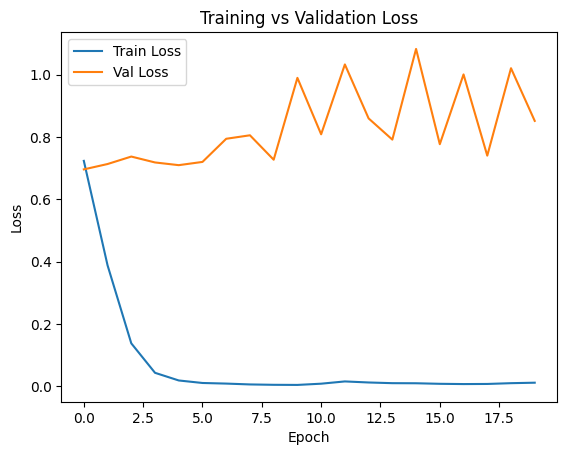

In [369]:
loss_history, eval_loss_history = train(model, train_dataloader, val_dataloader, criterion, optimizer, epochs=20)
plt.plot(loss_history,      label="Train Loss")
plt.plot(eval_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [370]:
from google.colab import drive
drive.mount('/content/drive')

# Save
torch.save(model.state_dict(), "/content/drive/MyDrive/neurossm.pth")

# Load
model.load_state_dict(torch.load("/content/drive/MyDrive/neurossm.pth"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<All keys matched successfully>

In [371]:
def evaluate(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for i, (batch_x, batch_y) in enumerate(dataloader):
            logits = model(batch_x.to("cuda"))
            preds = (torch.sigmoid(logits.squeeze()) > 0.5).long()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())

            print(f"\rEvaluating step {i+1}/{len(dataloader)}", end="")

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = (all_preds == all_labels).mean()
    tp = ((all_preds == 1) & (all_labels == 1)).sum()
    tn = ((all_preds == 0) & (all_labels == 0)).sum()
    fp = ((all_preds == 1) & (all_labels == 0)).sum()
    fn = ((all_preds == 0) & (all_labels == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)

    print(f"\n\n--- Evaluation Results ---")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"TP: {tp} | TN: {tn} | FP: {fp} | FN: {fn}")

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

model.eval()

results = evaluate(model, test_dataloader)

Evaluating step 3/3

--- Evaluation Results ---
Accuracy  : 0.6512
Precision : 0.6857
Recall    : 0.5581
F1 Score  : 0.6154
TP: 24 | TN: 32 | FP: 11 | FN: 19
